# Regroupement de tous mes codes 


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pymatgen as mg

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter

#import pour l'affichage des opérations de symétrie
from jupyter_jsmol.pymatgen import quick_view
from jupyter_jsmol.pymatgen import JsmolView
from pymatgen.io.cif import CifWriter
import plotly.graph_objects as go
from IPython.display import display





#import pymatviz as pv
# Exemple avec pymatgen (Materials Project)
#from mp_api.client import MPRester
from pymatgen.ext.matproj import MPRester  #j'ai mis celui l'autre import ne marche sur mon vscode 
from mp_api.client import MPRester



API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"  #id du LiC dans material project 

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(material_id)

    structure.to(fmt="cif", filename="LiC.cif")

structure






Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Structure Summary
Lattice
    abc : 3.591529777348829 4.011704109915074 4.011704492667927
 angles : 73.52458272493287 63.408171496645096 63.40816766642372
 volume : 45.96833740475323
      A : np.float64(3.20947838) np.float64(0.0) np.float64(1.61193507)
      B : np.float64(1.4266634900000001) np.float64(3.56532885) np.float64(1.16053063)
      C : np.float64(-0.0052797) np.float64(-0.023513299999999) np.float64(4.01163211)
    pbc : True True True
PeriodicSite: Li (3.492, 2.618, 5.05) [0.7607, 0.7393, 0.7393]
PeriodicSite: Li (1.139, 0.9233, 1.734) [0.2393, 0.2607, 0.2607]
PeriodicSite: C (1.24, 3.098, 1.532) [0.0, 0.8697, 0.1303]
PeriodicSite: C (0.1812, 0.444, 3.64) [-0.0, 0.1303, 0.8697]

In [2]:
import py3Dmol

with open("LiC.cif","r") as f:
    cif_cotent = f.read()

viewer = py3Dmol.view(width=800,height=(500))

viewer.addModel(cif_cotent,"cif")
viewer.setStyle({"sphere": {"scale": 0.3}})

# Fond noir
viewer.setBackgroundColor("white")

# Afficher la maille cristalline
viewer.addUnitCell()

# Zoom automatique
viewer.zoomTo()
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

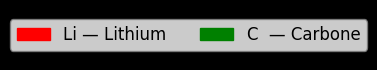

In [3]:
import py3Dmol
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pymatgen.io.cif import CifWriter
from mp_api.client import MPRester

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

# ✅ Pas de supercell, on utilise directement la structure
structure.to(fmt="cif", filename="LiC.cif")

with open("LiC.cif", "r") as f:
    cif_content = f.read()

# ── Viewer ─────────────────────────────────────────────────────────────────
viewer = py3Dmol.view(width=800, height=500)
viewer.addModel(cif_content, "cif")
viewer.setStyle({"elem": "Li"}, {"sphere": {"scale": 0.4, "color": "red"}})
viewer.setStyle({"elem": "C"},  {"sphere": {"scale": 0.3, "color": "green"}})
viewer.setBackgroundColor("white")
viewer.addUnitCell()
viewer.zoomTo()
viewer.show()

# ── Légende matplotlib ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 0.8), facecolor="black")
ax.set_facecolor("black")
ax.axis("off")

legende = [
    mpatches.Patch(color="red",   label="Li — Lithium"),
    mpatches.Patch(color="green", label="C  — Carbone"),
]

ax.legend(
    handles=legende,
    loc="center",
    ncol=2,
    fontsize=12,
    facecolor="white",
    labelcolor="black",
    edgecolor="gray",
)

plt.tight_layout()
plt.show()

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

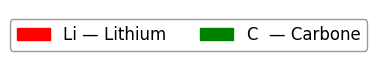

In [4]:
import py3Dmol
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mp_api.client import MPRester

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

structure.to(fmt="cif", filename="LiC.cif")

with open("LiC.cif", "r") as f:
    cif_content = f.read()

viewer = py3Dmol.view(width=800, height=500)
viewer.addModel(cif_content, "cif")

# ✅ Rayons ioniques réels (Li+ = 0.76Å, C = 0.77Å → tailles proches)
# ✅ Style ball-and-stick comme JSmol
viewer.setStyle({"elem": "Li"}, {
    "sphere": {"scale": 0.25, "color": "red"},
    "stick":  {"radius": 0.1,  "color": "gray"}
})
viewer.setStyle({"elem": "C"}, {
    "sphere": {"scale": 0.2,  "color": "green"},
    "stick":  {"radius": 0.1, "color": "gray"}
})

# ✅ Ajouter les liaisons entre atomes
viewer.addStyle({}, {"stick": {"radius": 0.1, "color": "gray"}})

viewer.setBackgroundColor("white")
viewer.addUnitCell()

# ✅ Axes cristallographiques comme JSmol
viewer.addArrow({
    "start": {"x": 0, "y": 0, "z": 0},
    "end":   {"x": 4, "y": 0, "z": 0},
    "color": "red", "radius": 0.1
})
viewer.addLabel("a", {
    "position": {"x": 4.3, "y": 0, "z": 0},
    "fontColor": "red", "fontSize": 14,
    "showBackground": False
})

viewer.addArrow({
    "start": {"x": 0, "y": 0, "z": 0},
    "end":   {"x": 0, "y": 4, "z": 0},
    "color": "green", "radius": 0.1
})
viewer.addLabel("b", {
    "position": {"x": 0, "y": 4.3, "z": 0},
    "fontColor": "green", "fontSize": 14,
    "showBackground": False
})

viewer.addArrow({
    "start": {"x": 0, "y": 0, "z": 0},
    "end":   {"x": 0, "y": 0, "z": 4},
    "color": "blue", "radius": 0.1
})
viewer.addLabel("c", {
    "position": {"x": 0, "y": 0, "z": 4.3},
    "fontColor": "blue", "fontSize": 14,
    "showBackground": False
})

viewer.zoomTo()
viewer.show()

# ── Légende matplotlib ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 0.8), facecolor="white")
ax.set_facecolor("white")
ax.axis("off")

legende = [
    mpatches.Patch(color="red",   label="Li — Lithium"),
    mpatches.Patch(color="green", label="C  — Carbone"),
]

ax.legend(
    handles=legende,
    loc="center",
    ncol=2,
    fontsize=12,
    facecolor="white",
    labelcolor="black",
    edgecolor="gray",
)

plt.tight_layout()
plt.show()

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Atome  : Li
Avant  : [0.     0.5    0.2393]
Après  : [ 0.     -0.5     0.2393]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

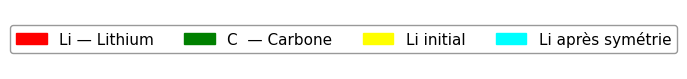

In [6]:
import py3Dmol
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
import numpy as np

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

# ── Opération de symétrie ──────────────────────────────────────────────────
sga     = SpacegroupAnalyzer(structure)
symmops = sga.get_symmetry_operations()

i_atom   = 0
i_symmop = 2

symmop    = symmops[i_symmop]
pos_init  = structure.sites[i_atom].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Atome  : {structure.sites[i_atom].species_string}")
print(f"Avant  : {np.round(pos_init, 4)}")
print(f"Après  : {np.round(pos_final, 4)}")

# Coordonnées cartésiennes
coords_init  = structure.lattice.get_cartesian_coords(pos_init).tolist()
coords_final = structure.lattice.get_cartesian_coords(pos_final).tolist()

# ── CIF ───────────────────────────────────────────────────────────────────
structure.to(fmt="cif", filename="LiC.cif")
with open("LiC.cif", "r") as f:
    cif_content = f.read()

# ── Viewer ─────────────────────────────────────────────────────────────────
viewer = py3Dmol.view(width=800, height=600)
viewer.addModel(cif_content, "cif")

# Style ball-and-stick
viewer.setStyle({"elem": "Li"}, {
    "sphere": {"scale": 0.25, "color": "red"},
})
viewer.setStyle({"elem": "C"}, {
    "sphere": {"scale": 0.2, "color": "green"},
})
viewer.addStyle({}, {"stick": {"radius": 0.08, "color": "gray"}})

# ── Atome initial (jaune, plus grand) ─────────────────────────────────────
viewer.addSphere({
    "center": {"x": coords_init[0],
                "y": coords_init[1],
                "z": coords_init[2]},
    "radius": 0.6,
    "color":  "yellow",
    "opacity": 0.9
})
viewer.addLabel("Initial", {
    "position": {"x": coords_init[0],
                 "y": coords_init[1],
                 "z": coords_init[2] + 0.8},
    "fontColor":        "yellow",
    "fontSize":         14,
    "fontOpacity":      1,
    "showBackground":   True,
    "backgroundColor":  "black",
    "backgroundOpacity": 0.5
})

# ── Atome final (cyan, plus grand) ────────────────────────────────────────
viewer.addSphere({
    "center": {"x": coords_final[0],
                "y": coords_final[1],
                "z": coords_final[2]},
    "radius": 0.6,
    "color":  "cyan",
    "opacity": 0.9
})
viewer.addLabel("Après symétrie", {
    "position": {"x": coords_final[0],
                 "y": coords_final[1],
                 "z": coords_final[2] + 0.8},
    "fontColor":        "cyan",
    "fontSize":         14,
    "fontOpacity":      1,
    "showBackground":   True,
    "backgroundColor":  "black",
    "backgroundOpacity": 0.5
})

# ── Flèche entre les deux positions ───────────────────────────────────────
viewer.addArrow({
    "start":  {"x": coords_init[0],
                "y": coords_init[1],
                "z": coords_init[2]},
    "end":    {"x": coords_final[0],
                "y": coords_final[1],
                "z": coords_final[2]},
    "color":  "orange",
    "radius": 0.12
})

# ── Axes cristallographiques ───────────────────────────────────────────────
lattice = structure.lattice.matrix
scale   = 0.8  # longueur des axes affichés

for vec, label, color in zip(lattice, ["a", "b", "c"],
                                       ["red", "green", "blue"]):
    direction = vec / np.linalg.norm(vec) * scale * np.linalg.norm(vec)
    viewer.addArrow({
        "start":  {"x": 0, "y": 0, "z": 0},
        "end":    {"x": float(direction[0]),
                   "y": float(direction[1]),
                   "z": float(direction[2])},
        "color":  color,
        "radius": 0.1
    })
    viewer.addLabel(label, {
        "position": {"x": float(direction[0] * 1.2),
                     "y": float(direction[1] * 1.2),
                     "z": float(direction[2] * 1.2)},
        "fontColor":       color,
        "fontSize":        16,
        "fontBold":        True,
        "showBackground":  False
    })

# ── Infos maille ───────────────────────────────────────────────────────────
lp = structure.lattice
sg = structure.get_space_group_info()
viewer.addLabel(
    f"HM: {sg[0]}  #{sg[1]}\n"
    f"a={lp.a:.3f} Å  b={lp.b:.3f} Å  c={lp.c:.3f} Å\n"
    f"α={lp.alpha:.1f}°  β={lp.beta:.1f}°  γ={lp.gamma:.1f}°\n"
    f"Op.#{i_symmop}: {np.round(pos_init,3)} → {np.round(pos_final,3)}",
    {
        "useScreen":        True,
        "screenOffset":     {"x": -380, "y": 260},
        "fontColor":        "white",
        "fontSize":         12,
        "fontOpacity":      1,
        "showBackground":   True,
        "backgroundColor":  "black",
        "backgroundOpacity": 0.6
    }
)

viewer.setBackgroundColor("white")
viewer.addUnitCell()
viewer.zoomTo()
viewer.show()

# ── Légende matplotlib ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 0.9), facecolor="white")
ax.set_facecolor("white")
ax.axis("off")

legende = [
    mpatches.Patch(color="red",    label="Li — Lithium"),
    mpatches.Patch(color="green",  label="C  — Carbone"),
    mpatches.Patch(color="yellow", label="Li initial"),
    mpatches.Patch(color="cyan",   label="Li après symétrie"),
]

ax.legend(
    handles=legende,
    loc="center",
    ncol=4,
    fontsize=11,
    facecolor="white",
    labelcolor="black",
    edgecolor="gray",
)

plt.tight_layout()
plt.show()

#### Opération de symétie

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Opération : Rot:
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]
tau
[0. 0. 0.]
Atome     : Li
Avant     : [0.     0.5    0.2393]
Après     : [ 0.     -0.5     0.2393]
Après %1  : [0.     0.5    0.2393]


c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


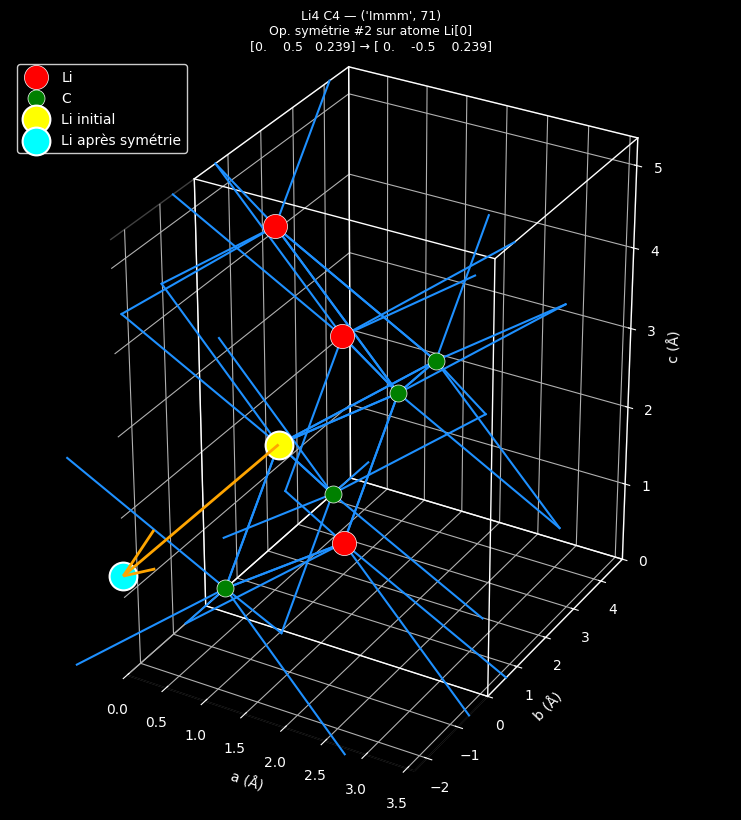

In [5]:
from mp_api.client import MPRester
from pymatgen.core.operations import SymmOp
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.local_env import CrystalNN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

# Récupérer les opérations de symétrie
sga = SpacegroupAnalyzer(structure)
symmops = sga.get_symmetry_operations()

# Choisir un atome et une opération de symétrie
i_atom   = 0  # index de l'atome Li
i_symmop = 2  # index de l'opération (pas l'identité)

symmop    = symmops[i_symmop]
pos_init  = structure.sites[i_atom].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Opération : {symmop}")
print(f"Atome     : {structure.sites[i_atom].species_string}")
print(f"Avant     : {np.round(pos_init, 4)}")
print(f"Après     : {np.round(pos_final, 4)}")
print(f"Après %1  : {np.round(pos_final % 1, 4)}")

# ── Visualisation ──────────────────────────────────────────────────────────
couleurs = {"Li": "red", "C": "green"}
tailles  = {"Li": 300,   "C": 150}

fig = plt.figure(figsize=(10, 8), facecolor="black")
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("black")

# ── 1. Liaisons ────────────────────────────────────────────────────────────
cnn = CrystalNN()
for i, site in enumerate(structure.sites):
    try:
        for neighbor in cnn.get_nn_info(structure, i):
            sj = neighbor["site"]
            ax.plot([site.coords[0], sj.coords[0]],
                    [site.coords[1], sj.coords[1]],
                    [site.coords[2], sj.coords[2]],
                    color="dodgerblue", linewidth=1.5, zorder=1)
    except:
        pass

# ── 2. Tous les atomes (structure inchangée) ───────────────────────────────
for i, site in enumerate(structure.sites):
    elem = site.species_string
    x, y, z = site.coords
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "white"),
               s=tailles.get(elem, 150),
               zorder=2,
               edgecolors="white",
               linewidths=0.5,
               label=elem)

# ── 3. Montrer le mapping de l'atome choisi ────────────────────────────────
coords_init  = structure.lattice.get_cartesian_coords(pos_init)
coords_final = structure.lattice.get_cartesian_coords(pos_final)

ax.scatter(*coords_init, color="yellow", s=400,
           zorder=5, edgecolors="white", linewidths=1.5,
           label="Li initial")

ax.scatter(*coords_final, color="cyan", s=400,
           zorder=5, edgecolors="white", linewidths=1.5,
           label="Li après symétrie")

ax.quiver(*coords_init,
          *(coords_final - coords_init),
          color="orange", linewidth=2, arrow_length_ratio=0.2,
          zorder=6)

# ── 4. Arêtes de la maille ─────────────────────────────────────────────────
lattice = structure.lattice.matrix
vecs    = [lattice[0], lattice[1], lattice[2]]
origin  = np.array([0, 0, 0])
edges   = [
    (origin,          vecs[0]),
    (origin,          vecs[1]),
    (origin,          vecs[2]),
    (vecs[0],         vecs[0]+vecs[1]),
    (vecs[0],         vecs[0]+vecs[2]),
    (vecs[1],         vecs[1]+vecs[0]),
    (vecs[1],         vecs[1]+vecs[2]),
    (vecs[2],         vecs[2]+vecs[0]),
    (vecs[2],         vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]
for start, end in edges:
    ax.plot(*zip(start, end), color="white", linewidth=1, zorder=0)

# ── 5. ✅ Corriger les proportions des axes ────────────────────────────────
lp = structure.lattice

# Ratio réel a, b, c
ax.set_box_aspect([lp.a, lp.b, lp.c])

# Limites basées sur les vrais coins cartésiens de la maille
all_corners = np.array([
    i*vecs[0] + j*vecs[1] + k*vecs[2]
    for i in range(2)
    for j in range(2)
    for k in range(2)
])

# Étendre les limites pour inclure pos_final si hors maille
all_points = np.vstack([all_corners, coords_init, coords_final])
ax.set_xlim(all_points[:, 0].min(), all_points[:, 0].max())
ax.set_ylim(all_points[:, 1].min(), all_points[:, 1].max())
ax.set_zlim(all_points[:, 2].min(), all_points[:, 2].max())

# ── 6. Légende et titre ────────────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(),
          facecolor="black", labelcolor="white", edgecolor="white")

ax.set_title(
    f"{structure.formula} — {structure.get_space_group_info()}\n"
    f"Op. symétrie #{i_symmop} sur atome "
    f"{structure.sites[i_atom].species_string}[{i_atom}]\n"
    f"{np.round(pos_init, 3)} → {np.round(pos_final, 3)}",
    color="white", fontsize=9
)
ax.set_xlabel("a (Å)", color="white")
ax.set_ylabel("b (Å)", color="white")
ax.set_zlabel("c (Å)", color="white")
ax.tick_params(colors="white")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("gray")
ax.yaxis.pane.set_edgecolor("gray")
ax.zaxis.pane.set_edgecolor("gray")

plt.tight_layout()
plt.savefig("Op_symetrie.png", dpi=150, facecolor="black")
plt.show()

In [ ]:
from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.local_env import CrystalNN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

sga      = SpacegroupAnalyzer(structure)
symmops  = sga.get_symmetry_operations()

i_atom   = 0
i_symmop = 2

symmop    = symmops[i_symmop]
pos_init  = structure.sites[i_atom].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Atome  : {structure.sites[i_atom].species_string}")
print(f"Avant  : {np.round(pos_init, 4)}")
print(f"Après  : {np.round(pos_final, 4)}")

# ── Couleurs et tailles ────────────────────────────────────────────────────
couleurs = {"Li": "#FF4444", "C": "#44AA44"}
tailles  = {"Li": 400,       "C": 200}

# ── Figure fond BLANC ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 8), facecolor="white")
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("white")

# ── 1. Liaisons (seulement premier voisin, plus lisible) ───────────────────
cnn = CrystalNN()
deja_traces = set()

for i, site in enumerate(structure.sites):
    try:
        for neighbor in cnn.get_nn_info(structure, i):
            j   = neighbor["site_index"]
            sj  = neighbor["site"]
            key = tuple(sorted([i, j]))
            if key not in deja_traces:
                deja_traces.add(key)
                ax.plot([site.coords[0], sj.coords[0]],
                        [site.coords[1], sj.coords[1]],
                        [site.coords[2], sj.coords[2]],
                        color="#4488CC", linewidth=2, zorder=1,
                        solid_capstyle="round")
    except:
        pass

# ── 2. Atomes (transparents comme JSmol) ──────────────────────────────────
for i, site in enumerate(structure.sites):
    elem = site.species_string
    x, y, z = site.coords
    # Sphère principale
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "gray"),
               s=tailles.get(elem, 200),
               zorder=2,
               edgecolors="white",
               linewidths=1,
               label=elem,
               alpha=0.9)
    # ✅ Halo transparent (comme JSmol)
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "gray"),
               s=tailles.get(elem, 200) * 3,
               zorder=1,
               alpha=0.15,
               linewidths=0)

# ── 3. Atome initial (jaune) et final (cyan) ──────────────────────────────
coords_init  = structure.lattice.get_cartesian_coords(pos_init)
coords_final = structure.lattice.get_cartesian_coords(pos_final)

# Halo atome initial
ax.scatter(*coords_init, color="gold", s=1200,
           zorder=4, alpha=0.2, linewidths=0)
ax.scatter(*coords_init, color="gold", s=450,
           zorder=5, edgecolors="darkorange",
           linewidths=2, label="Li initial")

# Halo atome final
ax.scatter(*coords_final, color="cyan", s=1200,
           zorder=4, alpha=0.2, linewidths=0)
ax.scatter(*coords_final, color="cyan", s=450,
           zorder=5, edgecolors="steelblue",
           linewidths=2, label="Li après symétrie")

# ── 4. Flèche orange épaisse (comme JSmol) ────────────────────────────────
deplacement = coords_final - coords_init
ax.quiver(*coords_init,
          *deplacement,
          color="darkorange", linewidth=3,
          arrow_length_ratio=0.15,
          zorder=6)

# ── 5. Arêtes de la maille en gris foncé ──────────────────────────────────
lattice = structure.lattice.matrix
vecs    = [lattice[0], lattice[1], lattice[2]]
origin  = np.array([0, 0, 0])
edges   = [
    (origin,          vecs[0]),
    (origin,          vecs[1]),
    (origin,          vecs[2]),
    (vecs[0],         vecs[0]+vecs[1]),
    (vecs[0],         vecs[0]+vecs[2]),
    (vecs[1],         vecs[1]+vecs[0]),
    (vecs[1],         vecs[1]+vecs[2]),
    (vecs[2],         vecs[2]+vecs[0]),
    (vecs[2],         vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]
for start, end in edges:
    ax.plot(*zip(start, end), color="#333333", linewidth=1.2, zorder=0)

# ── 6. Axes cristallographiques colorés (comme JSmol) ─────────────────────
scale = 0.4  # longueur des axes
axes_colors = {"a": "red", "b": "darkgreen", "c": "blue"}
for vec, (label, color) in zip(vecs, axes_colors.items()):
    direction = vec / np.linalg.norm(vec) * scale * np.linalg.norm(vec)
    ax.quiver(*origin, *direction,
              color=color, linewidth=2.5,
              arrow_length_ratio=0.2, zorder=7)
    ax.text(*(origin + direction * 1.15),
            label, color=color, fontsize=11, fontweight="bold")

# ── 7. Proportions et limites ──────────────────────────────────────────────
lp = structure.lattice
ax.set_box_aspect([lp.a, lp.b, lp.c])

all_corners = np.array([
    i*vecs[0] + j*vecs[1] + k*vecs[2]
    for i in range(2) for j in range(2) for k in range(2)
])
all_points = np.vstack([all_corners, coords_init, coords_final])
ax.set_xlim(all_points[:, 0].min(), all_points[:, 0].max())
ax.set_ylim(all_points[:, 1].min(), all_points[:, 1].max())
ax.set_zlim(all_points[:, 2].min(), all_points[:, 2].max())

# ── 8. Infos maille (coin supérieur gauche comme JSmol) ───────────────────
info = (f"HM: {structure.get_space_group_info()[0]}\n"
        f"a={lp.a:.3f} Å\nb={lp.b:.3f} Å\nc={lp.c:.3f} Å\n"
        f"α={lp.alpha:.1f}°\nβ={lp.beta:.1f}°\nγ={lp.gamma:.1f}°")
ax.text2D(0.02, 0.95, info, transform=ax.transAxes,
          fontsize=8, verticalalignment="top",
          fontfamily="monospace", color="black")

# ── 9. Légende et titre ───────────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(),
          facecolor="white", edgecolor="gray", fontsize=9)

ax.set_title(
    f"Op. symétrie #{i_symmop} — "
    f"{structure.sites[i_atom].species_string}[{i_atom}]\n"
    f"{np.round(pos_init,3)} → {np.round(pos_final,3)}",
    fontsize=10, color="black"
)
ax.set_xlabel("a (Å)"); ax.set_ylabel("b (Å)"); ax.set_zlabel("c (Å)")
ax.tick_params(colors="black")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("#CCCCCC")
ax.yaxis.pane.set_edgecolor("#CCCCCC")
ax.zaxis.pane.set_edgecolor("#CCCCCC")
ax.grid(True, color="#EEEEEE", linewidth=0.5)

plt.tight_layout()
plt.savefig("Op_symetrie.png", dpi=150, facecolor="white")
plt.show()

In [ ]:
from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.local_env import CrystalNN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

sga      = SpacegroupAnalyzer(structure)
symmops  = sga.get_symmetry_operations()

i_atom   = 0
i_symmop = 2

symmop    = symmops[i_symmop]
pos_init  = structure.sites[i_atom].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Atome  : {structure.sites[i_atom].species_string}")
print(f"Avant  : {np.round(pos_init, 4)}")
print(f"Après  : {np.round(pos_final, 4)}")

# ── Couleurs et tailles ────────────────────────────────────────────────────
couleurs = {"Li": "#FF4444", "C": "#44AA44"}
tailles  = {"Li": 400,       "C": 200}

# ── Figure fond BLANC ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 8), facecolor="white")
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("white")

# ── 1. Atomes avec réplication périodique sur la maille conventionnelle ───
# On génère tous les atomes visibles : ceux dans [0,1]³ + images aux frontières
def get_all_sites_with_images(structure):
    """
    Retourne la liste (coords_cart, elem, frac_coords_original) 
    pour tous les atomes visibles dans/sur la maille conventionnelle.
    On replique sur -1..1 et on garde ceux dont les coords fractionnaires
    tombent dans [-0.01, 1.01] (tolérance pour les atomes aux faces/sommets).
    """
    sites_to_draw = []
    for site in structure.sites:
        frac = site.frac_coords % 1.0  # ramène dans [0,1[
        elem = site.species_string
        # Générer les images dans {0,1} pour chaque coord fractionnaire proche de 0 ou 1
        images = [[frac[0]], [frac[1]], [frac[2]]]
        for k in range(3):
            if frac[k] < 0.01:
                images[k].append(1.0)
            if frac[k] > 0.99:
                images[k].append(0.0)
        for fx in images[0]:
            for fy in images[1]:
                for fz in images[2]:
                    cart = structure.lattice.get_cartesian_coords([fx, fy, fz])
                    sites_to_draw.append((cart, elem, np.array([fx, fy, fz])))
    return sites_to_draw

all_sites = get_all_sites_with_images(structure)

# ── 2. Liaisons ────────────────────────────────────────────────────────────
cnn = CrystalNN()
deja_traces = set()

for i, site in enumerate(structure.sites):
    try:
        for neighbor in cnn.get_nn_info(structure, i):
            j   = neighbor["site_index"]
            sj  = neighbor["site"]
            key = tuple(sorted([i, j]))
            if key not in deja_traces:
                deja_traces.add(key)
                ax.plot([site.coords[0], sj.coords[0]],
                        [site.coords[1], sj.coords[1]],
                        [site.coords[2], sj.coords[2]],
                        color="#4488CC", linewidth=2, zorder=1,
                        solid_capstyle="round")
    except:
        pass

# ── 3. Tracé des atomes répliqués ─────────────────────────────────────────
drawn_labels = set()
for cart, elem, frac in all_sites:
    x, y, z = cart
    label = elem if elem not in drawn_labels else "_nolegend_"
    drawn_labels.add(elem)
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "gray"),
               s=tailles.get(elem, 200),
               zorder=2,
               edgecolors="white",
               linewidths=1,
               label=label,
               alpha=0.9)
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "gray"),
               s=tailles.get(elem, 200) * 3,
               zorder=1,
               alpha=0.15,
               linewidths=0)

# ── 4. Nœuds du réseau de Bravais I (sommets + centre) ───────────────────
# Réseau I = nœuds aux 8 sommets (0,0,0) et au centre (½,½,½)
lattice = structure.lattice.matrix
vecs    = [lattice[0], lattice[1], lattice[2]]
origin  = np.array([0, 0, 0])

# 8 sommets de la maille conventionnelle
corners = np.array([
    i*vecs[0] + j*vecs[1] + k*vecs[2]
    for i in range(2) for j in range(2) for k in range(2)
])

# Centre (½,½,½) — nœud caractéristique du réseau I
center = 0.5*vecs[0] + 0.5*vecs[1] + 0.5*vecs[2]

# Tracé des nœuds du réseau de Bravais (grands cercles noirs transparents)
for idx, corner in enumerate(corners):
    label = "Nœuds réseau I (sommets)" if idx == 0 else "_nolegend_"
    ax.scatter(*corner, color="black", s=600, zorder=8,
               alpha=0.35, linewidths=0, label=label)
    ax.scatter(*corner, color="black", s=180, zorder=9,
               edgecolors="#222222", linewidths=1.5,
               facecolors="none", label="_nolegend_")

# Nœud central (½,½,½) — mis en évidence en violet
ax.scatter(*center, color="#9B59B6", s=800, zorder=8,
           alpha=0.4, linewidths=0, label="_nolegend_")
ax.scatter(*center, color="#9B59B6", s=300, zorder=9,
           edgecolors="#6C3483", linewidths=2,
           facecolors="#9B59B6", alpha=0.85,
           label="Nœud central (½,½,½) → réseau I")

# Annotation du nœud central
ax.text(center[0]+0.1, center[1]+0.1, center[2]+0.2,
        "(½,½,½)", fontsize=9, color="#6C3483", fontweight="bold", zorder=10)

# ── 5. Lignes reliant les sommets au centre (caractérisant le réseau I) ───
for corner in corners:
    ax.plot(*zip(corner, center),
            color="#9B59B6", linewidth=0.8, linestyle="--",
            alpha=0.5, zorder=3)

# ── 6. Atome initial (jaune) et final (cyan) ──────────────────────────────
coords_init  = structure.lattice.get_cartesian_coords(pos_init)
coords_final = structure.lattice.get_cartesian_coords(pos_final)

ax.scatter(*coords_init, color="gold", s=1200,
           zorder=4, alpha=0.2, linewidths=0)
ax.scatter(*coords_init, color="gold", s=450,
           zorder=5, edgecolors="darkorange",
           linewidths=2, label="Li initial")

ax.scatter(*coords_final, color="cyan", s=1200,
           zorder=4, alpha=0.2, linewidths=0)
ax.scatter(*coords_final, color="cyan", s=450,
           zorder=5, edgecolors="steelblue",
           linewidths=2, label="Li après symétrie")

# ── 7. Flèche orange épaisse ──────────────────────────────────────────────
deplacement = coords_final - coords_init
ax.quiver(*coords_init, *deplacement,
          color="darkorange", linewidth=3,
          arrow_length_ratio=0.15, zorder=6)

# ── 8. Arêtes de la maille en gris foncé ──────────────────────────────────
edges = [
    (origin,          vecs[0]),
    (origin,          vecs[1]),
    (origin,          vecs[2]),
    (vecs[0],         vecs[0]+vecs[1]),
    (vecs[0],         vecs[0]+vecs[2]),
    (vecs[1],         vecs[1]+vecs[0]),
    (vecs[1],         vecs[1]+vecs[2]),
    (vecs[2],         vecs[2]+vecs[0]),
    (vecs[2],         vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]
for start, end in edges:
    ax.plot(*zip(start, end), color="#333333", linewidth=1.5, zorder=0)

# ── 9. Axes cristallographiques colorés ───────────────────────────────────
scale = 0.4
axes_colors = {"a": "red", "b": "darkgreen", "c": "blue"}
for vec, (label, color) in zip(vecs, axes_colors.items()):
    direction = vec / np.linalg.norm(vec) * scale * np.linalg.norm(vec)
    ax.quiver(*origin, *direction,
              color=color, linewidth=2.5,
              arrow_length_ratio=0.2, zorder=7)
    ax.text(*(origin + direction * 1.15),
            label, color=color, fontsize=11, fontweight="bold")

# ── 10. Proportions et limites ─────────────────────────────────────────────
lp = structure.lattice
ax.set_box_aspect([lp.a, lp.b, lp.c])

all_points = np.vstack([corners, center, coords_init, coords_final])
ax.set_xlim(all_points[:, 0].min(), all_points[:, 0].max())
ax.set_ylim(all_points[:, 1].min(), all_points[:, 1].max())
ax.set_zlim(all_points[:, 2].min(), all_points[:, 2].max())

# ── 11. Infos maille ──────────────────────────────────────────────────────
info = (f"HM: {structure.get_space_group_info()[0]}\n"
        f"Réseau de Bravais: I (centré corps)\n"
        f"a={lp.a:.3f} Å\nb={lp.b:.3f} Å\nc={lp.c:.3f} Å\n"
        f"α={lp.alpha:.1f}°\nβ={lp.beta:.1f}°\nγ={lp.gamma:.1f}°")
ax.text2D(0.02, 0.95, info, transform=ax.transAxes,
          fontsize=8, verticalalignment="top",
          fontfamily="monospace", color="black")

# ── 12. Légende et titre ──────────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(),
          facecolor="white", edgecolor="gray", fontsize=9,
          loc="upper right")

ax.set_title(
    f"Réseau de Bravais Immm — maille conventionnelle\n"
    f"Op. symétrie #{i_symmop} — "
    f"{structure.sites[i_atom].species_string}[{i_atom}] : "
    f"{np.round(pos_init,3)} → {np.round(pos_final,3)}",
    fontsize=10, color="black"
)
ax.set_xlabel("a (Å)"); ax.set_ylabel("b (Å)"); ax.set_zlabel("c (Å)")
ax.tick_params(colors="black")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("#CCCCCC")
ax.yaxis.pane.set_edgecolor("#CCCCCC")
ax.zaxis.pane.set_edgecolor("#CCCCCC")
ax.grid(True, color="#EEEEEE", linewidth=0.5)

plt.tight_layout()
plt.savefig("Op_symetrie.png", dpi=150, facecolor="white")
plt.show()

In [ ]:
import scipy.interpolate as _si
if not hasattr(_si, 'make_splrep'):
    _si.make_splrep = _si.splrep

from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.local_env import CrystalNN
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

sga     = SpacegroupAnalyzer(structure)
symmops = sga.get_symmetry_operations()

i_atom   = 0
i_symmop = 2
symmop    = symmops[i_symmop]
pos_init  = structure.sites[i_atom].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Atome  : {structure.sites[i_atom].species_string}")
print(f"Avant  : {np.round(pos_init, 4)}")
print(f"Après  : {np.round(pos_final, 4)}")

# ── Couleurs et tailles ────────────────────────────────────────────────────
couleurs = {"Li": "#E8524A", "C": "#4CAF50"}   # rouge vif / vert vif
tailles  = {"Li": 500,       "C": 250}

# ── Figure fond BLANC ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 10), facecolor="white")
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("white")

# Angle de vue proche de l'image de référence
ax.view_init(elev=20, azim=-60)

# ── Panneaux avec grille visible (style image droite) ─────────────────────
ax.xaxis.pane.fill = True
ax.yaxis.pane.fill = True
ax.zaxis.pane.fill = True
ax.xaxis.pane.set_facecolor("#F5F5F5")
ax.yaxis.pane.set_facecolor("#F5F5F5")
ax.zaxis.pane.set_facecolor("#F5F5F5")
ax.xaxis.pane.set_edgecolor("#AAAAAA")
ax.yaxis.pane.set_edgecolor("#AAAAAA")
ax.zaxis.pane.set_edgecolor("#AAAAAA")
ax.grid(True, color="#CCCCCC", linewidth=0.8, linestyle="-")

# ── 1. Atomes répliqués ────────────────────────────────────────────────────
def get_all_sites_with_images(structure):
    sites_to_draw = []
    for site in structure.sites:
        frac = site.frac_coords % 1.0
        elem = site.species_string
        images = [[frac[0]], [frac[1]], [frac[2]]]
        for k in range(3):
            if frac[k] < 0.01:
                images[k].append(1.0)
            if frac[k] > 0.99:
                images[k].append(0.0)
        for fx in images[0]:
            for fy in images[1]:
                for fz in images[2]:
                    cart = structure.lattice.get_cartesian_coords([fx, fy, fz])
                    sites_to_draw.append((cart, elem, np.array([fx, fy, fz])))
    return sites_to_draw

all_sites = get_all_sites_with_images(structure)


# ── 3. Tracé des atomes ────────────────────────────────────────────────────
drawn_labels = set()
for cart, elem, frac in all_sites:
    x, y, z = cart
    label = elem if elem not in drawn_labels else "_nolegend_"
    drawn_labels.add(elem)
    # Halo large semi-transparent
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "gray"),
               s=tailles.get(elem, 250) * 3.5,
               zorder=1, alpha=0.18, linewidths=0)
    # Atome principal avec contour blanc
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "gray"),
               s=tailles.get(elem, 250),
               zorder=2,
               edgecolors="white", linewidths=1.5,
               label=label, alpha=0.95)

# ── 4. Nœuds du réseau de Bravais I ───────────────────────────────────────
lattice = structure.lattice.matrix
vecs    = [lattice[0], lattice[1], lattice[2]]
origin  = np.array([0, 0, 0])

corners = np.array([
    i*vecs[0] + j*vecs[1] + k*vecs[2]
    for i in range(2) for j in range(2) for k in range(2)
])
center = 0.5*vecs[0] + 0.5*vecs[1] + 0.5*vecs[2]

for idx, corner in enumerate(corners):
    label = "Nœuds réseau I (sommets)" if idx == 0 else "_nolegend_"
    # Halo gris
    ax.scatter(*corner, color="#444444", s=700, zorder=8,
               alpha=0.25, linewidths=0, label=label)
    # Cercle avec contour bien visible
    ax.scatter(*corner, color="white", s=220, zorder=9,
               edgecolors="#222222", linewidths=2.0)

# Nœud central (½,½,½) — violet bien visible
ax.scatter(*center, color="#9B59B6", s=900, zorder=8,
           alpha=0.35, linewidths=0)
ax.scatter(*center, color="#9B59B6", s=360, zorder=9,
           edgecolors="#6C3483", linewidths=2.2,
           label="Nœud central (½,½,½) → réseau I")

ax.text(center[0]+0.12, center[1]+0.12, center[2]+0.25,
        "(½,½,½)", fontsize=10, color="#6C3483",
        fontweight="bold", zorder=10)

# ── 5. Lignes vers le centre (réseau I) ───────────────────────────────────
for corner in corners:
    ax.plot(*zip(corner, center),
            color="#9B59B6", linewidth=1.0, linestyle="--",
            alpha=0.45, zorder=3)

# ── 6. Atome initial (jaune) et final (cyan) ──────────────────────────────
coords_init  = structure.lattice.get_cartesian_coords(pos_init)
coords_final = structure.lattice.get_cartesian_coords(pos_final)

# Initial — jaune/orange, halo large
ax.scatter(*coords_init, color="gold", s=1600,
           zorder=4, alpha=0.25, linewidths=0)
ax.scatter(*coords_init, color="gold", s=560,
           zorder=5, edgecolors="darkorange",
           linewidths=2.5, label="Li initial")

# Final — cyan, halo large
ax.scatter(*coords_final, color="cyan", s=1600,
           zorder=4, alpha=0.25, linewidths=0)
ax.scatter(*coords_final, color="cyan", s=560,
           zorder=5, edgecolors="#1A7ABF",
           linewidths=2.5, label="Li après symétrie")

# ── 7. Flèche de déplacement (épaisse, orange) ────────────────────────────
deplacement = coords_final - coords_init
ax.quiver(*coords_init, *deplacement,
          color="darkorange", linewidth=4,
          arrow_length_ratio=0.18, zorder=6)

# ── 8. Arêtes de la maille (noir/gris foncé) ──────────────────────────────
edges = [
    (origin,          vecs[0]),
    (origin,          vecs[1]),
    (origin,          vecs[2]),
    (vecs[0],         vecs[0]+vecs[1]),
    (vecs[0],         vecs[0]+vecs[2]),
    (vecs[1],         vecs[1]+vecs[0]),
    (vecs[1],         vecs[1]+vecs[2]),
    (vecs[2],         vecs[2]+vecs[0]),
    (vecs[2],         vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]
for start, end in edges:
    ax.plot(*zip(start, end),
            color="#222222", linewidth=2.0, zorder=0, alpha=0.85)

# ── 9. Axes cristallographiques colorés et allongés ───────────────────────
scale = 0.5   # plus long que 0.4
axes_colors = {"a": "red", "b": "darkgreen", "c": "blue"}
for vec, (label_ax, color) in zip(vecs, axes_colors.items()):
    direction = vec / np.linalg.norm(vec) * scale * np.linalg.norm(vec)
    ax.quiver(*origin, *direction,
              color=color, linewidth=3.0,
              arrow_length_ratio=0.18, zorder=7)
    ax.text(*(origin + direction * 1.2),
            label_ax, color=color, fontsize=13, fontweight="bold")

# ── 10. Proportions et limites ─────────────────────────────────────────────
lp = structure.lattice
ax.set_box_aspect([lp.a, lp.b, lp.c])

all_points = np.vstack([corners, center, coords_init, coords_final])
margin = 0.3
ax.set_xlim(all_points[:, 0].min() - margin, all_points[:, 0].max() + margin)
ax.set_ylim(all_points[:, 1].min() - margin, all_points[:, 1].max() + margin)
ax.set_zlim(all_points[:, 2].min() - margin, all_points[:, 2].max() + margin)

# ── 11. Infos maille dans un cadre (coin haut gauche) ─────────────────────
info = (f"HM: {structure.get_space_group_info()[0]}\n"
        f"Réseau de Bravais: I (centré corps)\n"
        f"a={lp.a:.3f} Å\nb={lp.b:.3f} Å\nc={lp.c:.3f} Å\n"
        f"α={lp.alpha:.1f}°\nβ={lp.beta:.1f}°\nγ={lp.gamma:.1f}°")
ax.text2D(0.02, 0.97, info,
          transform=ax.transAxes,
          fontsize=8.5,
          verticalalignment="top",
          fontfamily="monospace",
          color="black",
          bbox=dict(boxstyle="round,pad=0.4",
                    facecolor="white",
                    edgecolor="#AAAAAA",
                    alpha=0.90,
                    linewidth=1.0))

# ── 12. Légende stylisée (coin haut droit, image de référence) ────────────
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

legend = ax.legend(
    unique.values(), unique.keys(),
    facecolor="white",
    edgecolor="#999999",
    fontsize=9.5,
    loc="upper right",
    framealpha=0.95,
    borderpad=0.8,
    labelspacing=0.6,
    handlelength=1.5,
    handleheight=1.2,
    borderaxespad=0.5,
    fancybox=True,          # coins arrondis comme l'image droite
    shadow=False,
)
legend.get_frame().set_linewidth(1.2)

# ── 13. Titre détaillé (deux lignes) ──────────────────────────────────────
ax.set_title(
    f"Réseau de Bravais Immm — maille conventionnelle\n"
    f"Op. symétrie #{i_symmop} — "
    f"{structure.sites[i_atom].species_string}[{i_atom}] : "
    f"[{' '.join(f'{v:.3f}' for v in np.round(pos_init,3))}]"
    f" → [{' '.join(f'{v:.3f}' for v in np.round(pos_final,3))}]",
    fontsize=11,
    color="black",
    pad=12,
)

# ── 14. Axes avec labels et ticks lisibles ────────────────────────────────
ax.set_xlabel("a (Å)", fontsize=10, labelpad=8, color="#333333")
ax.set_ylabel("b (Å)", fontsize=10, labelpad=8, color="#333333")
ax.set_zlabel("c (Å)", fontsize=10, labelpad=8, color="#333333")
ax.tick_params(colors="#555555", labelsize=8)

plt.tight_layout()
plt.savefig("Op_symetrie.png", dpi=180, facecolor="white",
            bbox_inches="tight")
plt.show()

## Vitesse du son 

In [ ]:
import numpy as np

def find_acoustic_branches(frequencies, threshold=0.5):
    frequence = []
    branche = []
    zone = []
    
    for i in range(len(frequencies)):  # boucle sur les segments
        n_branches = frequencies[i].shape[1]  # phonopy: (n_qpoints, n_branches)
        
        for j in range(n_branches):  # boucle sur les branches
            # Extraire la branche j du segment i : tous les qpoints
            freq_branch = frequencies[i][:, j]  # ← correction clé : [:, j] au lieu de [j]
            
            # Condition : fréquence quasi-nulle au début OU à la fin du segment
            if (abs(freq_branch[0]) < threshold or abs(freq_branch[-1]) < threshold) \
                and j not in branche and i not in zone:
                zone.append(i)
                branche.append(j)
                frequence.append(freq_branch)
    
    return frequence, branche, zone

acoustic_branches = find_acoustic_branches(frequency)
frequences_acoustiques, indices_branches, indices_zones = acoustic_branches

print("Branches acoustiques :", indices_branches)
print("Zones correspondantes :", indices_zones)

# Récupérer distances et fréquences pour chaque branche acoustique
q1 = distances[indices_zones[0]]
q2 = distances[indices_zones[1]]
q3 = distances[indices_zones[2]]

f1 = frequency[indices_zones[0]][:, indices_branches[0]]
f2 = frequency[indices_zones[1]][:, indices_branches[1]]
f3 = frequency[indices_zones[2]][:, indices_branches[2]]